In [4]:
"""
Ex . Structure-Constrained Resistivity Inversion
===========================================

This example demonstrates how to incorporate structural information from 
seismic velocity models into ERT inversion for improved subsurface imaging.

The workflow includes:
1. Loading seismic travel time data and performing velocity inversion
2. Extracting velocity interfaces at specified thresholds
3. Creating ERT meshes with geological layer boundaries
4. Structure-constrained ERT inversion using velocity-derived interfaces
5. Comparison with unconstrained inversion results

Structure-constrained inversion significantly improves the accuracy of 
resistivity models by incorporating a priori geological information,
leading to more reliable hydrological interpretations.
"""

'\nEx . Structure-Constrained Resistivity Inversion\n===========================================\n\nThis example demonstrates how to incorporate structural information from \nseismic velocity models into ERT inversion for improved subsurface imaging.\n\nThe workflow includes:\n1. Loading seismic travel time data and performing velocity inversion\n2. Extracting velocity interfaces at specified thresholds\n3. Creating ERT meshes with geological layer boundaries\n4. Structure-constrained ERT inversion using velocity-derived interfaces\n5. Comparison with unconstrained inversion results\n\nStructure-constrained inversion significantly improves the accuracy of \nresistivity models by incorporating a priori geological information,\nleading to more reliable hydrological interpretations.\n'

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
from pygimli.physics import ert
import pygimli.physics.traveltime as tt
import os
import sys
import matplotlib.pylab as pylab

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.inversion.time_lapse import TimeLapseERTInversion
from PyHydroGeophysX.core.mesh_utils import MeshCreator,add_velocity_interface,createTriangles,extract_velocity_interface
# Set up matplotlib parameters
params = {'legend.fontsize': 15,
         'axes.labelsize': 14,
         'axes.titlesize':14,
         'xtick.labelsize':14,
         'ytick.labelsize':14}
pylab.rcParams.update(params)
plt.rcParams["font.family"] = "Arial"

### 1. load ERT and SRT data

In [7]:
# load seismic data
ttData = tt.load("../examples/results/workflow_example/synthetic_seismic_data.dat")
# load ERT data
ertData = ert.load("../examples/results/TL_measurements/appres/synthetic_data30.dat")

### 2. Set up inversion domain

In [8]:
# using ERT data to create a mesh to take care of the boundary
paraBoundary = 0.1

ert1 = ert.ERTManager(ertData)
grid = ert1.createMesh(data=ertData,quality = 31,paraDX=0.5, paraMaxCellSize=2, boundaryMaxCellSize=3000,smooth=[2, 2],
                       paraBoundary = paraBoundary, paraDepth = 30.0)
ert1.setMesh(grid)
mesh = ert1.fop.paraDomain
mesh.setCellMarkers(np.ones((mesh.cellCount()))*2)

13/10/25 - 20:40:28 - pyGIMLi - INFO - Found 2 regions.
13/10/25 - 20:40:28 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
13/10/25 - 20:40:28 - pyGIMLi - INFO - Found 2 regions.
13/10/25 - 20:40:28 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
13/10/25 - 20:40:28 - pyGIMLi - INFO - Creating forward mesh from region infos.
13/10/25 - 20:40:28 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
13/10/25 - 20:40:28 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5661 Cells: 10936 Boundaries: 8394


### 3. Invert the seismic travel time data first

13/10/25 - 20:41:06 - pyGIMLi - INFO - Found 1 regions.
13/10/25 - 20:41:06 - pyGIMLi - INFO - Creating forward mesh from region infos.
13/10/25 - 20:41:06 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
13/10/25 - 20:41:06 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
13/10/25 - 20:41:06 - pyGIMLi - INFO - Created startmodel from forward operator:2119, min/max=0.000200/0.002000
13/10/25 - 20:41:06 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x00000223B4503D30>
Data transformation: Identity transform
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 0.00016666666666666666, upper bound 0.01
min/max (data): 0.0016/0.06
min/max (error): 4.35%/6.31%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   28.21
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.47 (dPhi = 93.96%) lam: 50.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    0.94 (dPhi = 31.99%) lam: 50.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.94)                   #
################################################################################


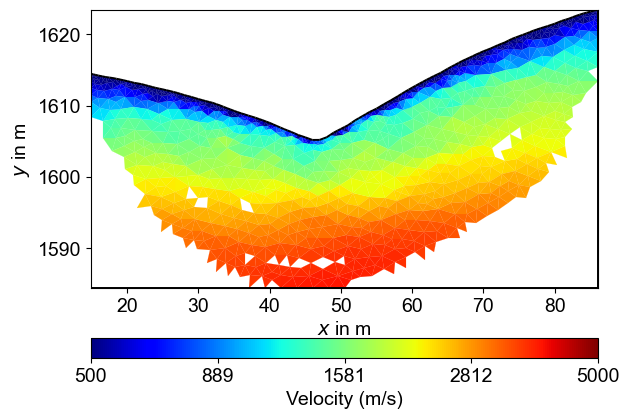

In [9]:
## travel time inversion

TT = pg.physics.traveltime.TravelTimeManager()
TT.setMesh(mesh)
TT.invert(ttData, lam=50,
          zWeight=0.2,vTop=500, vBottom=5000,
          verbose=1, limits=[100., 6000.])

ax, cbar = TT.showResult(cMap='jet',coverage=TT.standardizedCoverage(),cMin=500,cMax=5000)

### 4. Get the structure interface

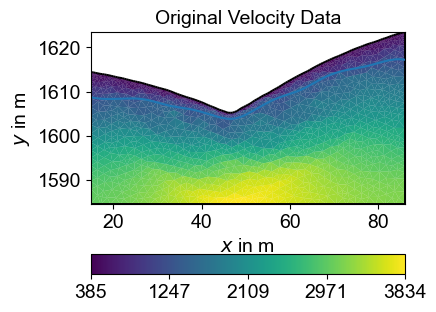

In [14]:
velocity_data = TT.model.array()
# Call the function with velocity data
smooth_x, smooth_z = extract_velocity_interface(mesh, velocity_data, threshold=1200,interval = 5)

fig, ax1 = plt.subplots(1, 1, figsize=(5, 3))

# Original data
pg.show(mesh, velocity_data, ax=ax1, cMap='viridis', colorBar=True)
ax1.set_title('Original Velocity Data')
ax1.plot(smooth_x, smooth_z)

### 4. Put structure interface into mesh for inversion

In [17]:
markers, mesh_with_interface = add_velocity_interface(ertData, smooth_x, smooth_z)
mesh_with_interface

Mesh: Nodes: 2806 Cells: 5400 Boundaries: 8205

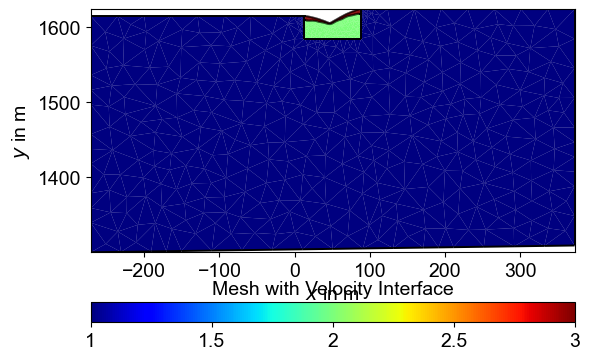

Mesh: Nodes: 2806 Cells: 5400 Boundaries: 8205

In [23]:
## chceck the mesh with interface
fig, ax = plt.subplots(figsize=(6, 4))
pg.show(mesh_with_interface, markers, ax=ax, cMap='jet', colorBar=True)
plt.title('Mesh with Velocity Interface')
plt.show()
mesh_with_interface

### 5. Inversion with the updated mesh

In [24]:
mgrConstrained = ert.ERTManager()
mgrConstrained.invert(data=ertData, verbose=True, lam=10, mesh=mesh_with_interface,limits=[1., 10000.])

13/10/25 - 20:56:08 - pyGIMLi - INFO - Found 3 regions.
13/10/25 - 20:56:08 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
13/10/25 - 20:56:08 - pyGIMLi - INFO - Creating forward mesh from region infos.
13/10/25 - 20:56:08 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
13/10/25 - 20:56:08 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11011 Cells: 21600 Boundaries: 16410
13/10/25 - 20:56:08 - pyGIMLi - INFO - Use median(data values)=627.1605183102331
13/10/25 - 20:56:08 - pyGIMLi - INFO - Created startmodel from forward operator:4515, min/max=627.160518/627.160518
13/10/25 - 20:56:08 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000223E18D1FD0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation (cumulative):
	 0 Logarithmic LU transform, lower bound 1.0, upper bound 10000.0
	 1 Logarithmic LU transform, lower bound 1.0, upper bound 10000.0
min/max (data): 430/1116
min/max (error): 5%/5%
min/max (start model): 627/627
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =    4.91
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    1.15 (dPhi = 72.57%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    0.99 (dPhi = 11.50%) lam: 10.0


################################################################################
#                  Abort criterion reached: chi² <= 1 (0.99)                   #
#########################################

4515 [765.7639532470903,...,896.8724789462541]

(<Axes: xlabel='Distance (m)', ylabel='Elevation (m)'>,
 <matplotlib.colorbar.Colorbar at 0x21270483450>)

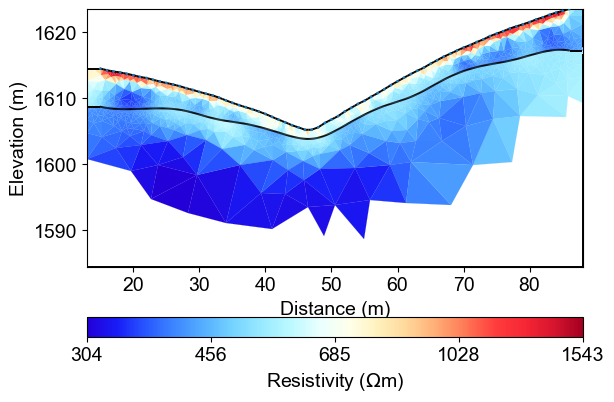

In [ ]:
from palettable.lightbartlein.diverging import BlueDarkRed18_18
fixed_cmap = BlueDarkRed18_18.mpl_colormap

res_cov = mgrConstrained.coverage()[mgrConstrained.paraDomain.cellMarkers()]>-1.0

mgrConstrained.showResult(xlabel="Distance (m)", ylabel="Elevation (m)",coverage = res_cov,cMap=fixed_cmap)

### 6. Save the mesh

In [25]:
mesh_with_interface.save("results/Structure_WC/mesh_with_interface.bms")

1